# Candidate Pairs Explorer

What-if threshold analysis on a single run's `candidate_pairs.parquet`.
No labels required — the file is auto-saved after every clustering run.

**Workflow**:
1. Set `RUN_DIR` below to point at any run output folder
2. Run all cells
3. Adjust gate thresholds in the **Gate Configuration** cell and re-run from there

**What this notebook covers**:
- Feature distributions for all candidate pairs
- Gate A/B/D pass/fail at configurable thresholds
- Threshold sweep: how many pairs survive as you tighten/loosen each gate
- Support count re-estimation at alternative thresholds (using stored percentiles)
- Top-pairs table sorted by any feature
- Scatter plots to visualise the decision boundary

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# --- Project root (two levels up from notebooks/face_clustering/) ---
PROJECT_ROOT = Path('../../')
RESULTS_DIR  = PROJECT_ROOT / 'results'

from face_cluster.export import load_candidate_pairs

# ============================================================
# SET THIS to the run you want to examine
# ============================================================
RUN_DIR = RESULTS_DIR / 'Google_Germany' / 'recluster_1'   # <-- change me
# ============================================================

print(f'Run dir: {RUN_DIR.resolve()}')
print(f'Exists : {RUN_DIR.exists()}')

Run dir: D:\sim-bench\results\Google_Germany\recluster_1
Exists : True


In [13]:
df = load_candidate_pairs(RUN_DIR)
df.columns

Index(['cluster_a', 'cluster_b', 'min_exemplar_dist', 'p10_exemplar_dist',
       'p25_exemplar_dist', 'exemplar_dist_mean', 'exemplar_dist_std',
       'min_cross_dist', 'p10_cross_dist', 'p25_cross_dist', 'p50_cross_dist',
       'p75_cross_dist', 'p90_cross_dist', 'cross_dist_iqr',
       'support_fraction', 'n_cross_pairs_below_threshold', 'size_a', 'size_b',
       'size_min', 'size_ratio', 'size_sum', 'diameter_a', 'diameter_b',
       'diameter_max', 'diameter_ratio', 'post_merge_diameter',
       'diameter_expansion', 'mean_intra_dist_a', 'mean_intra_dist_b',
       'exemplar_count_a', 'exemplar_count_b', 't_a', 't_b', 't_local',
       't_global', 'dist_to_threshold_ratio', 'n_images_a', 'n_images_b',
       'shared_source_images', 'shared_source_ratio', 'same_image_min_dist',
       'mean_blur_a', 'mean_blur_b', 'blur_min_a', 'blur_min_b',
       'frontal_frac_a', 'frontal_frac_b', 'frontal_frac_min', 'pose_diff',
       'yaw_std_a', 'yaw_std_b', 'mean_area_a', 'mean_area_b',

In [15]:
import re
[col for col in df.columns if re.search('diam', col)]

['diameter_a',
 'diameter_b',
 'diameter_max',
 'diameter_ratio',
 'post_merge_diameter',
 'diameter_expansion']

In [ ]:
# --- Load candidate_pairs.parquet ---

if df is None:
    raise FileNotFoundError(
        f'candidate_pairs.parquet not found in {RUN_DIR}\n'
        'Re-run clustering on this run to generate it '
        '(pipeline auto-saves after the exemplars stage).'
    )

print(f'Loaded {len(df)} candidate pairs')
print(f'Feature version : {df["feature_version"].iloc[0] if "feature_version" in df.columns else "n/a"}')
print(f'Saved at        : {df["saved_at"].iloc[0] if "saved_at" in df.columns else "n/a"}')
print(f'Clusters        : {sorted(set(df["cluster_a"]) | set(df["cluster_b"]))}')
print(f'\nAvailable columns ({len(df.columns)}):')
print(list(df.columns))
display(df[['cluster_a','cluster_b','min_exemplar_dist','p10_exemplar_dist',
            'p25_exemplar_dist','p10_cross_dist','diameter_a','diameter_b', 'post_merge_diameter',
            'size_a','size_b','diameter_expansion']].head(10))

Loaded 34 candidate pairs
Feature version : 4
Saved at        : 2026-04-27T22:50:22.942329
Clusters        : [0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22]

Available columns (56):
['cluster_a', 'cluster_b', 'min_exemplar_dist', 'p10_exemplar_dist', 'p25_exemplar_dist', 'exemplar_dist_mean', 'exemplar_dist_std', 'min_cross_dist', 'p10_cross_dist', 'p25_cross_dist', 'p50_cross_dist', 'p75_cross_dist', 'p90_cross_dist', 'cross_dist_iqr', 'support_fraction', 'n_cross_pairs_below_threshold', 'size_a', 'size_b', 'size_min', 'size_ratio', 'size_sum', 'diameter_a', 'diameter_b', 'diameter_max', 'diameter_ratio', 'post_merge_diameter', 'diameter_expansion', 'mean_intra_dist_a', 'mean_intra_dist_b', 'exemplar_count_a', 'exemplar_count_b', 't_a', 't_b', 't_local', 't_global', 'dist_to_threshold_ratio', 'n_images_a', 'n_images_b', 'shared_source_images', 'shared_source_ratio', 'same_image_min_dist', 'mean_blur_a', 'mean_blur_b', 'blur_min_a', 'blur_min_b', 'frontal_frac_

,cluster_a,cluster_b,min_exemplar_dist,p10_exemplar_dist,p25_exemplar_dist,p10_cross_dist,diameter_a,diameter_b,post_merge_diameter,size_a,size_b,diameter_expansion
0,1,17,0.309639,0.365501,0.387106,0.357432,0.712675,0.349623,0.712675,125,2,1.000000
1,1,5,0.359037,0.399465,0.437662,0.393478,0.712675,0.403328,0.733297,125,2,1.028936
2,4,18,0.365670,0.416852,0.442148,0.438474,0.578450,0.423576,0.655552,94,5,1.133291
3,0,11,0.377935,0.410178,0.445269,0.421926,0.772733,0.540906,0.802698,152,5,1.038778
4,3,4,0.401507,0.437443,0.480830,0.439414,0.460969,0.578450,0.713139,5,94,1.232845
5,2,13,0.455833,0.537403,0.574312,0.550247,0.790313,0.433559,0.794410,180,2,1.005184
6,7,12,0.473829,0.488710,0.512303,0.490848,0.419099,0.784606,0.784606,2,11,1.000000
7,0,2,0.477313,0.589383,0.625926,0.607143,0.772733,0.790313,0.966991,152,180,1.223555
8,2,16,0.492324,0.541914,0.579868,0.540694,0.790313,0.303482,0.801325,180,3,1.013934
9,12,19,0.505517,0.529619,0.647663,0.567251,0.784606,0.279016,0.828256,11,2,1.055632


: 

## 1. Feature Distributions

Histograms of key distance features across all candidate pairs.

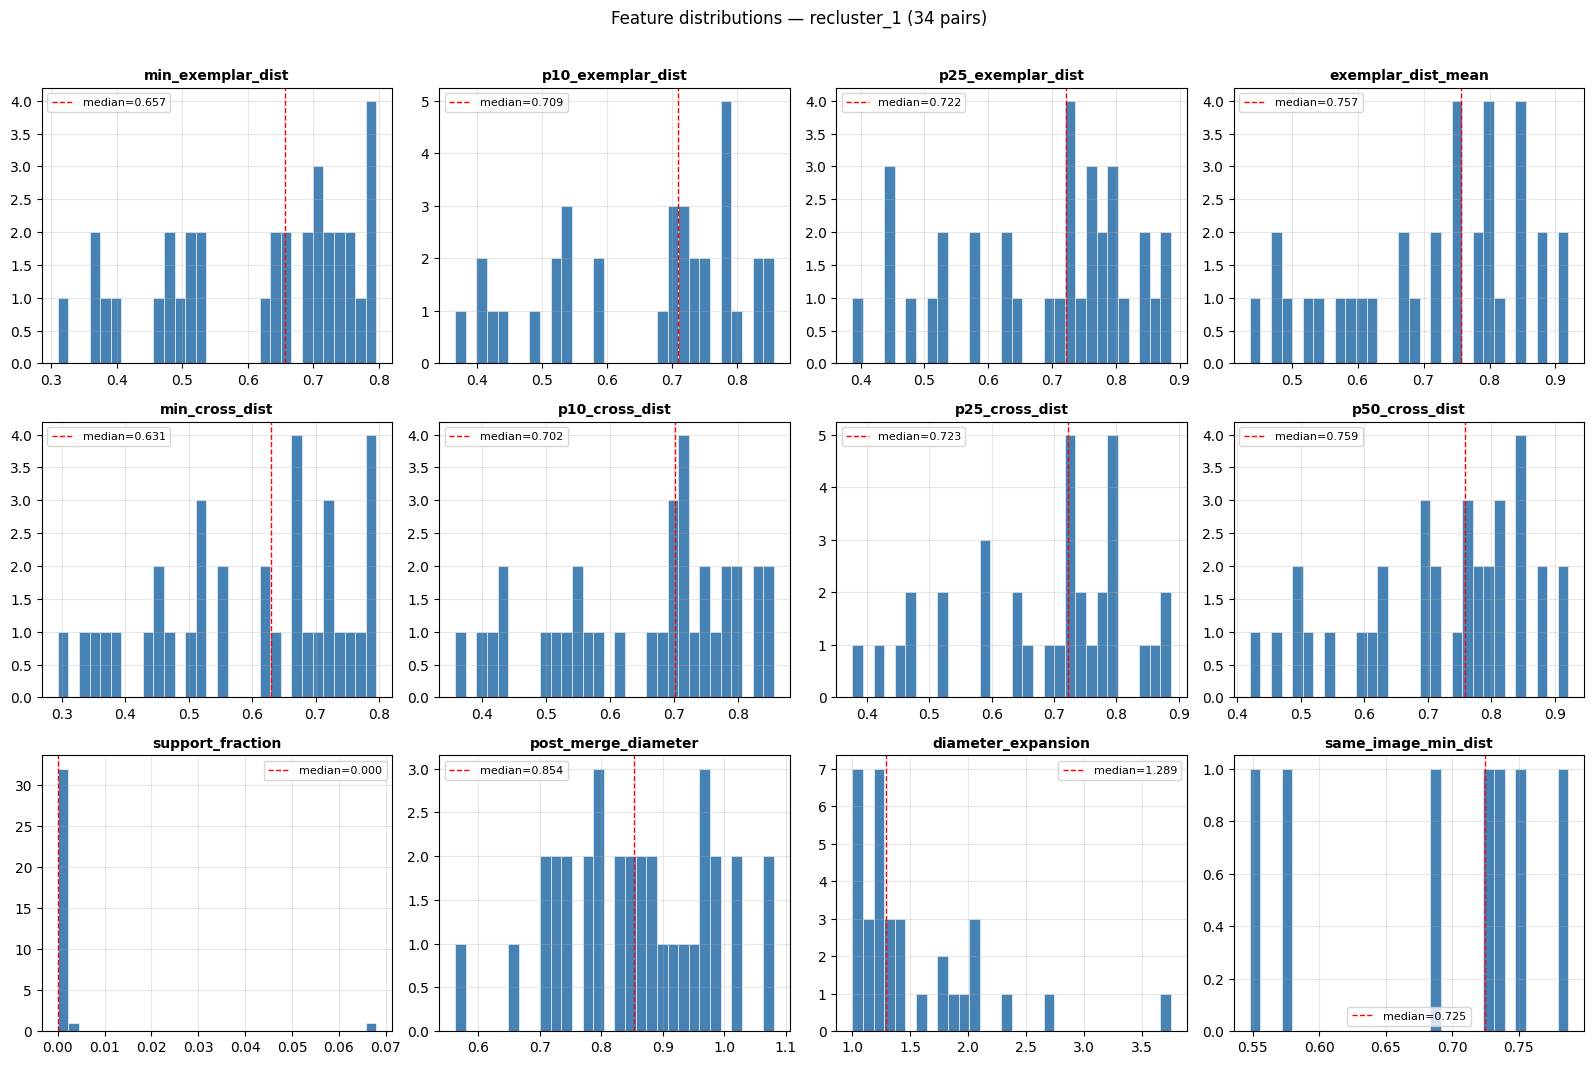

In [3]:
DIST_FEATURES = [
    'min_exemplar_dist', 'p10_exemplar_dist', 'p25_exemplar_dist',
    'exemplar_dist_mean',
    'min_cross_dist', 'p10_cross_dist', 'p25_cross_dist', 'p50_cross_dist',
    'support_fraction', 'post_merge_diameter', 'diameter_expansion',
    'same_image_min_dist',
]
present = [f for f in DIST_FEATURES if f in df.columns]

ncols = 4
nrows = (len(present) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows))
axes = axes.flatten()

for ax, feat in zip(axes, present):
    vals = df[feat].dropna()
    ax.hist(vals, bins=30, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    med = vals.median()
    ax.axvline(med, color='red', linestyle='--', linewidth=1, label=f'median={med:.3f}')
    ax.legend(fontsize=8)

for ax in axes[len(present):]:
    ax.set_visible(False)

fig.suptitle(f'Feature distributions — {RUN_DIR.name} ({len(df)} pairs)', fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

## 2. Gate Configuration

Edit thresholds here and re-run from this cell downward.

| Gate | Logic | Config param |
|------|-------|--------------|
| A | `min_exemplar_dist <= T_exemplar` | `merge_exemplar_threshold` |
| B | `n_cross_pairs_below_T >= max(min_size * frac, min_count)` | `merge_support_frac`, `merge_support_min` |
| D | `post_merge_diameter <= diameter_max * expansion` | `merge_diameter_expansion_factor` |

Gate C (margin vs next-best cluster) is not available as a per-pair feature.

In [4]:
# ============================================================
# Gate thresholds — edit these
# ============================================================
T_EXEMPLAR          = 0.55   # Gate A: merge_exemplar_threshold
T_SUPPORT           = 0.45   # Gate B: threshold for counting cross-pairs
MERGE_SUPPORT_FRAC  = 0.30   # Gate B: fraction of min(size_a, size_b)
MERGE_SUPPORT_MIN   = 2      # Gate B: absolute floor
DIAMETER_EXPANSION  = 1.5    # Gate D: expansion factor
# ============================================================

ORIGINAL_SUPPORT_THRESHOLD = 0.35  # threshold used when parquet was saved


# --- Gate B: re-estimate support count at T_SUPPORT via CDF interpolation ---
def estimate_support_at_threshold(df: pd.DataFrame, new_thresh: float) -> pd.Series:
    """Estimate n_cross_pairs_below_threshold at new_thresh from stored percentiles."""
    dist_cols = ['min_cross_dist','p10_cross_dist','p25_cross_dist',
                 'p50_cross_dist','p75_cross_dist','p90_cross_dist']
    frac_anchors = np.array([0.0, 0.10, 0.25, 0.50, 0.75, 0.90])
    n_total = (df['size_a'] * df['size_b']).values
    sub = df[dist_cols + ['support_fraction']].values
    results = []
    for i, row in enumerate(sub):
        d_pts = list(row[:6])
        f_pts = list(frac_anchors)
        sf = row[6]
        if not np.isnan(sf):
            d_pts.append(ORIGINAL_SUPPORT_THRESHOLD)
            f_pts.append(float(sf))
            order = np.argsort(d_pts)
            d_pts = np.array(d_pts)[order]
            f_pts = np.array(f_pts)[order]
        frac = float(np.interp(new_thresh, d_pts, f_pts))
        results.append(int(round(frac * n_total[i])))
    return pd.Series(results, index=df.index, name='n_cross_pairs_est')


# --- Evaluate gates ---
df['gate_a_pass'] = (df['min_exemplar_dist'] <= T_EXEMPLAR).astype(int)

df['_n_support_est'] = estimate_support_at_threshold(df, T_SUPPORT)
_size_min = df[['size_a','size_b']].min(axis=1)
_req = (_size_min * MERGE_SUPPORT_FRAC).clip(lower=MERGE_SUPPORT_MIN)
df['gate_b_pass'] = (df['_n_support_est'] >= _req).astype(int)
df.drop(columns=['_n_support_est'], inplace=True)

df['gate_d_pass'] = (
    df['post_merge_diameter'] <= df['diameter_max'] * DIAMETER_EXPANSION
).astype(int)

df['n_gates_passed'] = df['gate_a_pass'] + df['gate_b_pass'] + df['gate_d_pass']
df['all_gates_pass'] = (df['n_gates_passed'] == 3).astype(int)

print(f'Gate thresholds: A={T_EXEMPLAR}  B_support={T_SUPPORT}  D_expansion={DIAMETER_EXPANSION}')
print(f'Total pairs: {len(df)}')
print()
for g in ['gate_a_pass','gate_b_pass','gate_d_pass','all_gates_pass']:
    n = df[g].sum()
    print(f'  {g:18s}: {n:3d} / {len(df)} pass ({100*n/len(df):.0f}%)')
print()
print('n_gates_passed distribution:')
print(df['n_gates_passed'].value_counts().sort_index().to_frame('count'))

Gate thresholds: A=0.55  B_support=0.45  D_expansion=1.5
Total pairs: 34

  gate_a_pass       :  13 / 34 pass (38%)
  gate_b_pass       :   6 / 34 pass (18%)
  gate_d_pass       :  23 / 34 pass (68%)
  all_gates_pass    :   6 / 34 pass (18%)

n_gates_passed distribution:
                count
n_gates_passed       
0                  10
1                  12
2                   6
3                   6


## 3. Gate Sweep

How many pairs survive as you slide each gate threshold independently?

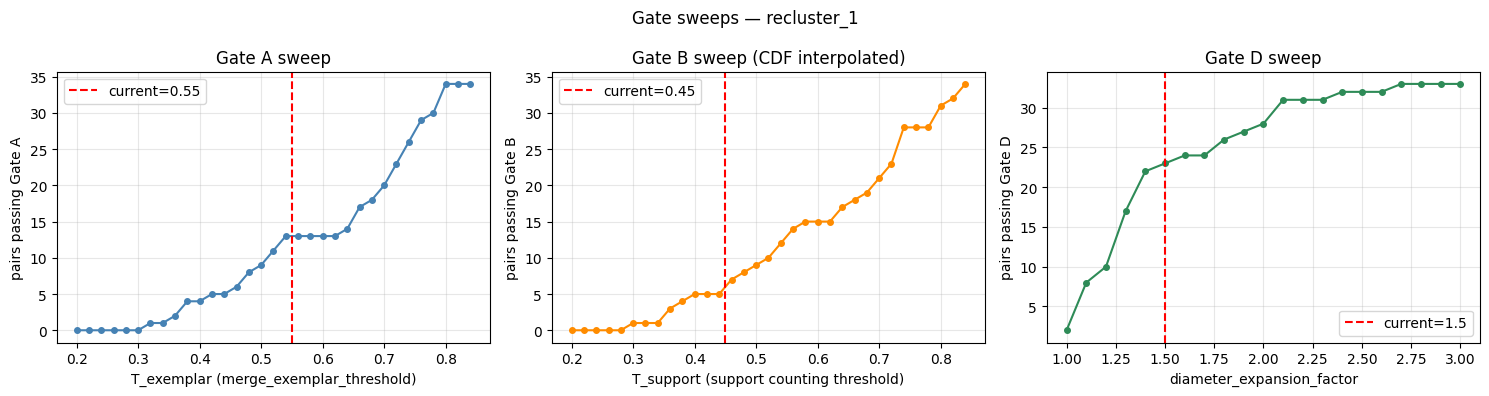

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gate A sweep
thresholds_a = np.arange(0.20, 0.85, 0.02)
pass_a = [(df['min_exemplar_dist'] <= t).sum() for t in thresholds_a]
axes[0].plot(thresholds_a, pass_a, 'o-', ms=4, color='steelblue')
axes[0].axvline(T_EXEMPLAR, color='red', linestyle='--', label=f'current={T_EXEMPLAR}')
axes[0].set_xlabel('T_exemplar (merge_exemplar_threshold)')
axes[0].set_ylabel('pairs passing Gate A')
axes[0].set_title('Gate A sweep')
axes[0].legend()

# Gate B sweep (uses CDF interpolation)
thresholds_b = np.arange(0.20, 0.85, 0.02)
pass_b = []
for t in thresholds_b:
    n_est = estimate_support_at_threshold(df, t)
    sm = df[['size_a','size_b']].min(axis=1)
    req = (sm * MERGE_SUPPORT_FRAC).clip(lower=MERGE_SUPPORT_MIN)
    pass_b.append((n_est >= req).sum())
axes[1].plot(thresholds_b, pass_b, 'o-', ms=4, color='darkorange')
axes[1].axvline(T_SUPPORT, color='red', linestyle='--', label=f'current={T_SUPPORT}')
axes[1].set_xlabel('T_support (support counting threshold)')
axes[1].set_ylabel('pairs passing Gate B')
axes[1].set_title('Gate B sweep (CDF interpolated)')
axes[1].legend()

# Gate D sweep
expansions = np.arange(1.0, 3.1, 0.1)
pass_d = [(df['post_merge_diameter'] <= df['diameter_max'] * e).sum() for e in expansions]
axes[2].plot(expansions, pass_d, 'o-', ms=4, color='seagreen')
axes[2].axvline(DIAMETER_EXPANSION, color='red', linestyle='--',
                label=f'current={DIAMETER_EXPANSION}')
axes[2].set_xlabel('diameter_expansion_factor')
axes[2].set_ylabel('pairs passing Gate D')
axes[2].set_title('Gate D sweep')
axes[2].legend()

fig.suptitle(f'Gate sweeps — {RUN_DIR.name}', fontsize=12)
fig.tight_layout()
plt.show()

## 4. All-Gates Sweep

How many pairs pass ALL three gates as `T_exemplar` and `T_support` vary together?

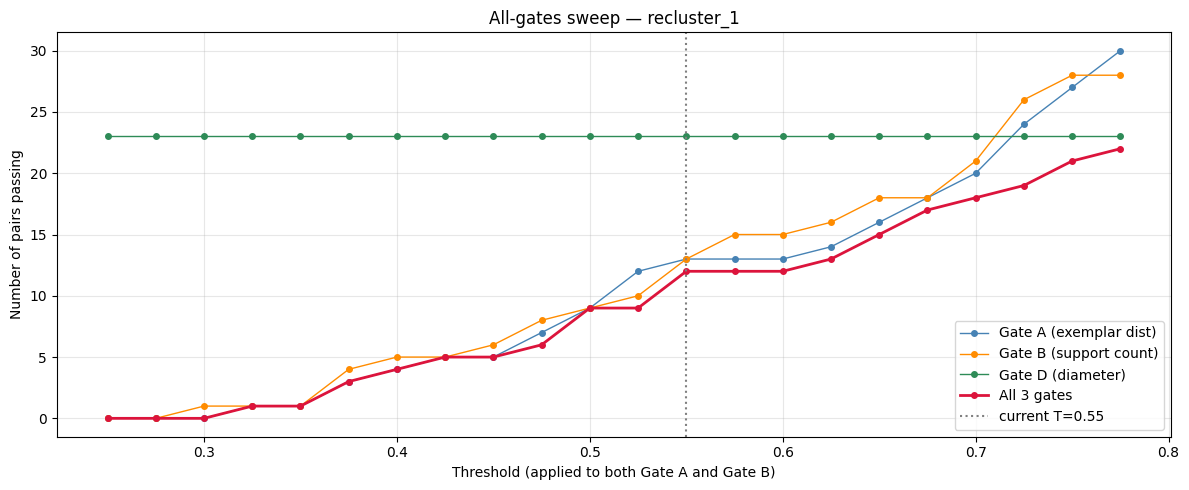

Pairs passing all 3 gates at selected thresholds:


In [6]:
t_vals = np.arange(0.25, 0.80, 0.025)
records = []
for t in t_vals:
    gate_a = (df['min_exemplar_dist'] <= t)
    n_est  = estimate_support_at_threshold(df, t)
    sm = df[['size_a','size_b']].min(axis=1)
    req = (sm * MERGE_SUPPORT_FRAC).clip(lower=MERGE_SUPPORT_MIN)
    gate_b = (n_est >= req)
    gate_d = (df['post_merge_diameter'] <= df['diameter_max'] * DIAMETER_EXPANSION)
    records.append({
        'threshold': t,
        'gate_a': gate_a.sum(),
        'gate_b': gate_b.sum(),
        'gate_d': gate_d.sum(),
        'all_3':  (gate_a & gate_b & gate_d).sum(),
    })

sweep = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(12, 5))
for col, label, color in [
    ('gate_a', 'Gate A (exemplar dist)',    'steelblue'),
    ('gate_b', 'Gate B (support count)',    'darkorange'),
    ('gate_d', 'Gate D (diameter)',         'seagreen'),
    ('all_3',  'All 3 gates',              'crimson'),
]:
    ax.plot(sweep['threshold'], sweep[col], 'o-', ms=4, label=label, color=color,
            linewidth=2 if col == 'all_3' else 1)
ax.axvline(T_EXEMPLAR, color='gray', linestyle=':', linewidth=1.5,
           label=f'current T={T_EXEMPLAR}')
ax.set_xlabel('Threshold (applied to both Gate A and Gate B)')
ax.set_ylabel('Number of pairs passing')
ax.set_title(f'All-gates sweep — {RUN_DIR.name}')
ax.legend()
fig.tight_layout()
plt.show()

print('Pairs passing all 3 gates at selected thresholds:')
for _, row in sweep[sweep['threshold'].isin(
        [round(t, 3) for t in np.arange(0.35, 0.70, 0.05)])].iterrows():
    print(f'  T={row.threshold:.2f}:  A={int(row.gate_a)}  B={int(row.gate_b)}  '
          f'D={int(row.gate_d)}  ALL={int(row.all_3)}')

## 5. Pairs Detail Table

All pairs sorted by exemplar distance. `gate_*` columns reflect the thresholds set in the Gate Configuration cell above.

In [7]:
# Columns to display — feel free to add/remove
DISPLAY_COLS = [
    'cluster_a', 'cluster_b',
    'size_a', 'size_b',
    'min_exemplar_dist', 'p10_exemplar_dist', 'p25_exemplar_dist',
    'p10_cross_dist', 'p25_cross_dist', 'p50_cross_dist',
    'support_fraction',
    'post_merge_diameter', 'diameter_expansion',
    'same_image_min_dist',
    'gate_a_pass', 'gate_b_pass', 'gate_d_pass', 'n_gates_passed',
]
present_cols = [c for c in DISPLAY_COLS if c in df.columns]

SORTED_BY = 'min_exemplar_dist'   # change to any column

table = df[present_cols].sort_values(SORTED_BY).reset_index(drop=True)

def _color_gate(val):
    if val == 1:
        return 'background-color: #d4edda'
    elif val == 0:
        return 'background-color: #f8d7da'
    return ''

gate_cols = [c for c in ['gate_a_pass','gate_b_pass','gate_d_pass','n_gates_passed']
             if c in table.columns]

float_cols = [c for c in table.columns if table[c].dtype == float]
display(
    table.style
    .format({c: '{:.3f}' for c in float_cols})
    .applymap(_color_gate, subset=gate_cols)
)

,cluster_a,cluster_b,size_a,size_b,min_exemplar_dist,p10_exemplar_dist,p25_exemplar_dist,p10_cross_dist,p25_cross_dist,p50_cross_dist,support_fraction,post_merge_diameter,diameter_expansion,same_image_min_dist,gate_a_pass,gate_b_pass,gate_d_pass,n_gates_passed
0,1,17,125,2,0.310,0.366,0.387,0.357,0.376,0.420,0.068,0.713,1.000,nan,1,1,1,3
1,1,5,125,2,0.359,0.399,0.438,0.393,0.420,0.454,0.004,0.733,1.029,nan,1,1,1,3
2,4,18,94,5,0.366,0.417,0.442,0.438,0.463,0.498,0.000,0.656,1.133,nan,1,1,1,3
3,0,11,152,5,0.378,0.410,0.445,0.422,0.454,0.499,0.001,0.803,1.039,nan,1,1,1,3
4,3,4,5,94,0.402,0.437,0.481,0.439,0.475,0.513,0.000,0.713,1.233,nan,1,1,1,3
5,2,13,180,2,0.456,0.537,0.574,0.550,0.589,0.629,0.000,0.794,1.005,nan,1,0,1,2
6,7,12,2,11,0.474,0.489,0.512,0.491,0.528,0.601,0.000,0.785,1.000,nan,1,0,1,2
7,0,2,152,180,0.477,0.589,0.626,0.607,0.644,0.688,0.000,0.967,1.224,0.548,1,1,1,3
8,2,16,180,3,0.492,0.542,0.580,0.541,0.584,0.629,0.000,0.801,1.014,nan,1,0,1,2
9,12,19,11,2,0.506,0.530,0.648,0.567,0.663,0.700,0.000,0.828,1.056,nan,1,0,1,2


## 6. Key Feature Scatters

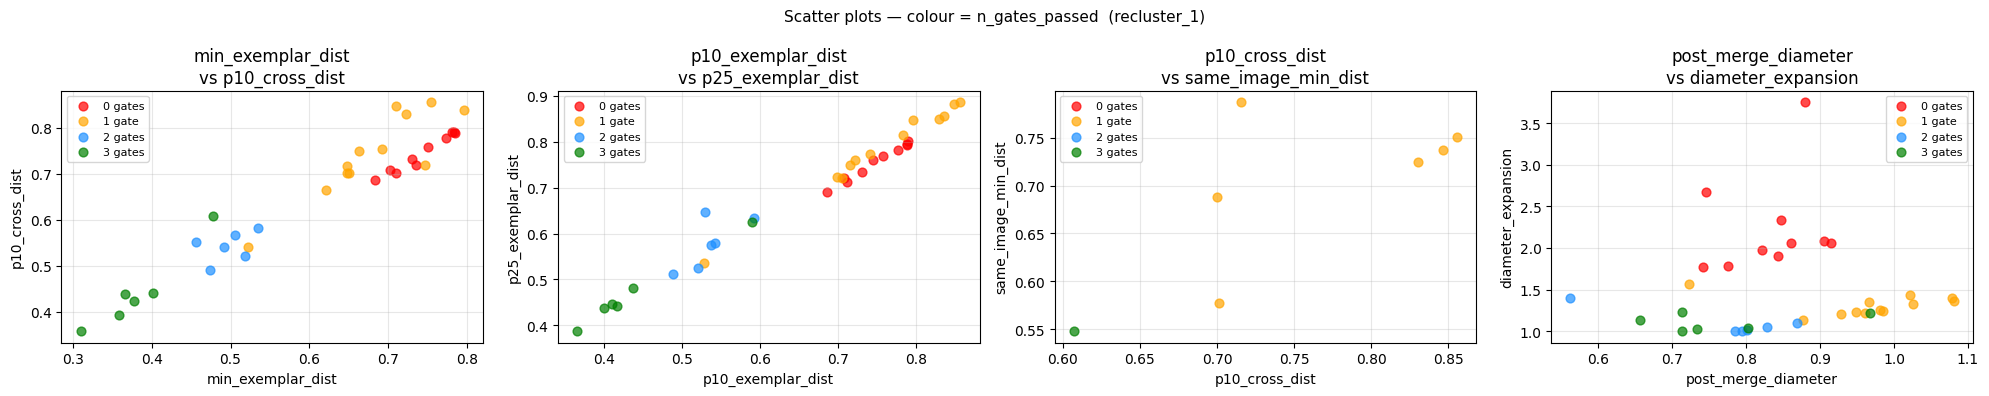

In [8]:
# Colour points by how many gates they pass
cmap = {0: 'red', 1: 'orange', 2: 'dodgerblue', 3: 'green'}
colors = df['n_gates_passed'].map(cmap).fillna('gray')
labels_legend = {0:'0 gates', 1:'1 gate', 2:'2 gates', 3:'3 gates'}

scatter_pairs = [
    ('min_exemplar_dist', 'p10_cross_dist'),
    ('p10_exemplar_dist', 'p25_exemplar_dist'),
    ('p10_cross_dist',    'same_image_min_dist'),
    ('post_merge_diameter', 'diameter_expansion'),
]
scatter_pairs = [(a, b) for a, b in scatter_pairs
                 if a in df.columns and b in df.columns]

fig, axes = plt.subplots(1, len(scatter_pairs), figsize=(5 * len(scatter_pairs), 4))
if len(scatter_pairs) == 1:
    axes = [axes]

for ax, (xcol, ycol) in zip(axes, scatter_pairs):
    for gate_val, color in cmap.items():
        mask = df['n_gates_passed'] == gate_val
        if mask.sum() == 0:
            continue
        ax.scatter(df.loc[mask, xcol], df.loc[mask, ycol],
                   c=color, alpha=0.7, s=40, label=labels_legend[gate_val], zorder=gate_val+1)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f'{xcol}\nvs {ycol}')
    ax.legend(fontsize=8)

fig.suptitle(f'Scatter plots — colour = n_gates_passed  ({RUN_DIR.name})', fontsize=11)
fig.tight_layout()
plt.show()

## 7. same_image_min_dist Analysis

`same_image_min_dist` is the strongest anti-merge signal: a small value means two clusters contain faces from the same photo — likely detection duplicates of the same face, not two different people. Pairs where this is NaN share no source images.

Pairs with shared source images: 7 / 34
Pairs without shared images    : 27 / 34


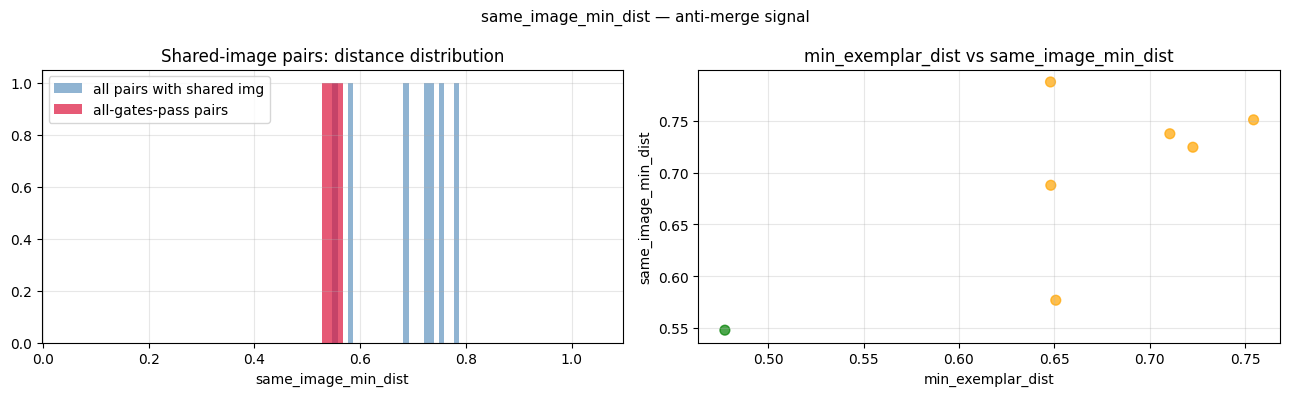


Suspicious pairs (all gates pass + same_image_min_dist < 0.3): 0


In [9]:
if 'same_image_min_dist' not in df.columns:
    print('same_image_min_dist not in dataset')
else:
    has_shared = df['same_image_min_dist'].notna()
    print(f'Pairs with shared source images: {has_shared.sum()} / {len(df)}')
    print(f'Pairs without shared images    : {(~has_shared).sum()} / {len(df)}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Distribution of same_image_min_dist
    vals = df.loc[has_shared, 'same_image_min_dist']
    all_pass = df.loc[has_shared & (df['all_gates_pass'] == 1), 'same_image_min_dist']
    axes[0].hist(vals, bins=25, alpha=0.6, color='steelblue', label='all pairs with shared img')
    if len(all_pass):
        axes[0].hist(all_pass, bins=25, alpha=0.7, color='crimson',
                     label='all-gates-pass pairs')
    axes[0].set_xlabel('same_image_min_dist')
    axes[0].set_title('Shared-image pairs: distance distribution')
    axes[0].legend()

    # same_image_min_dist vs min_exemplar_dist
    axes[1].scatter(
        df.loc[has_shared, 'min_exemplar_dist'],
        df.loc[has_shared, 'same_image_min_dist'],
        c=df.loc[has_shared, 'n_gates_passed'].map(cmap),
        alpha=0.7, s=50
    )
    axes[1].set_xlabel('min_exemplar_dist')
    axes[1].set_ylabel('same_image_min_dist')
    axes[1].set_title('min_exemplar_dist vs same_image_min_dist')

    fig.suptitle('same_image_min_dist — anti-merge signal', fontsize=11)
    fig.tight_layout()
    plt.show()

    # Suspicious pairs: all gates pass but share a source image with small dist
    SAME_IMG_THRESHOLD = 0.30
    suspicious = df[
        (df['all_gates_pass'] == 1) &
        has_shared &
        (df['same_image_min_dist'] < SAME_IMG_THRESHOLD)
    ]
    print(f'\nSuspicious pairs (all gates pass + same_image_min_dist < {SAME_IMG_THRESHOLD}): {len(suspicious)}')
    if len(suspicious):
        display(suspicious[['cluster_a','cluster_b','min_exemplar_dist',
                             'same_image_min_dist','n_gates_passed']]
                .sort_values('same_image_min_dist'))

## 8. Exemplar Distance Distribution

Compares `min_exemplar_dist`, `p10_exemplar_dist`, `p25_exemplar_dist` — the new V4 features.

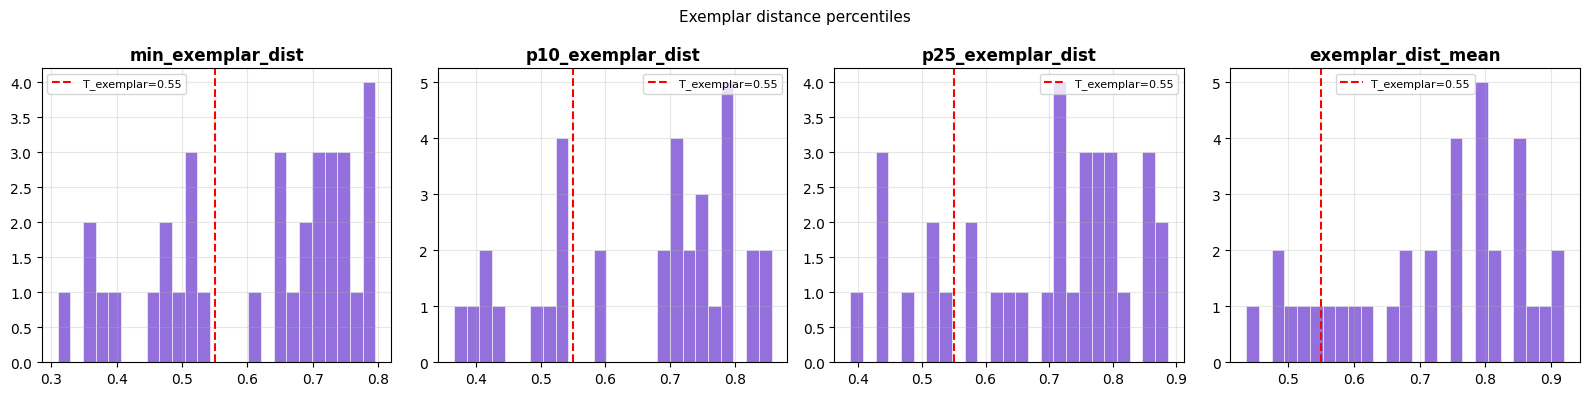


Correlation between exemplar distance features:


,min_exemplar_dist,p10_exemplar_dist,p25_exemplar_dist,exemplar_dist_mean
min_exemplar_dist,1.000,0.963,0.937,0.921
p10_exemplar_dist,0.963,1.000,0.990,0.983
p25_exemplar_dist,0.937,0.990,1.000,0.995
exemplar_dist_mean,0.921,0.983,0.995,1.000


  Pairs that pass T_exemplar=0.55 on p10_exemplar_dist but not min_exemplar_dist: 0
  Pairs that pass T_exemplar=0.55 on p25_exemplar_dist but not min_exemplar_dist: 0
  Pairs that pass T_exemplar=0.55 on exemplar_dist_mean but not min_exemplar_dist: 0


In [10]:
ex_cols = [c for c in ['min_exemplar_dist','p10_exemplar_dist','p25_exemplar_dist',
                        'exemplar_dist_mean'] if c in df.columns]

if len(ex_cols) < 2:
    print('Exemplar percentile features not present (run was saved with feature_version < 4)')
else:
    fig, axes = plt.subplots(1, len(ex_cols), figsize=(4 * len(ex_cols), 4))
    if len(ex_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, ex_cols):
        vals = df[col].dropna()
        ax.hist(vals, bins=25, color='mediumpurple', edgecolor='white', linewidth=0.4)
        ax.axvline(T_EXEMPLAR, color='red', linestyle='--', linewidth=1.5,
                   label=f'T_exemplar={T_EXEMPLAR}')
        ax.set_title(col, fontweight='bold')
        ax.legend(fontsize=8)
    fig.suptitle('Exemplar distance percentiles', fontsize=11)
    fig.tight_layout()
    plt.show()

    # Correlation between exemplar distance features
    print('\nCorrelation between exemplar distance features:')
    display(df[ex_cols].corr().round(3))

    # How many extra pairs would pass gate A using p10 vs min
    for col in ex_cols[1:]:
        extra = ((df[col] <= T_EXEMPLAR) & (df['min_exemplar_dist'] > T_EXEMPLAR)).sum()
        print(f'  Pairs that pass T_exemplar={T_EXEMPLAR} on {col} but not min_exemplar_dist: {extra}')

## 9. Summary

Snapshot of the current gate configuration and how many pairs survive.

In [11]:
print('=' * 55)
print(f'Run          : {RUN_DIR.name}')
print(f'Total pairs  : {len(df)}')
print(f'Clusters     : {len(set(df["cluster_a"]) | set(df["cluster_b"]))}')
print('-' * 55)
print(f'Gate A  T_exemplar          = {T_EXEMPLAR}')
print(f'Gate B  T_support           = {T_SUPPORT}')
print(f'        support_frac        = {MERGE_SUPPORT_FRAC}')
print(f'        support_min         = {MERGE_SUPPORT_MIN}')
print(f'Gate D  diameter_expansion  = {DIAMETER_EXPANSION}')
print('-' * 55)
for g in ['gate_a_pass','gate_b_pass','gate_d_pass']:
    n = int(df[g].sum())
    print(f'{g:20s} : {n:3d} / {len(df)} ({100*n/len(df):.0f}%)')
print('-' * 55)
all3 = int(df['all_gates_pass'].sum())
print(f'All 3 gates pass     : {all3:3d} / {len(df)} ({100*all3/len(df):.0f}%)')
print('=' * 55)

Run          : recluster_1
Total pairs  : 34
Clusters     : 20
-------------------------------------------------------
Gate A  T_exemplar          = 0.55
Gate B  T_support           = 0.45
        support_frac        = 0.3
        support_min         = 2
Gate D  diameter_expansion  = 1.5
-------------------------------------------------------
gate_a_pass          :  13 / 34 (38%)
gate_b_pass          :   6 / 34 (18%)
gate_d_pass          :  23 / 34 (68%)
-------------------------------------------------------
All 3 gates pass     :   6 / 34 (18%)
